# Assignment 6

## Data Augmentation

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-05-12

Course: Deep Machine Learning 4DT908

In [1]:
from numpy import zeros
from numpy import unique
from numpy import argmax
from numpy import asarray
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


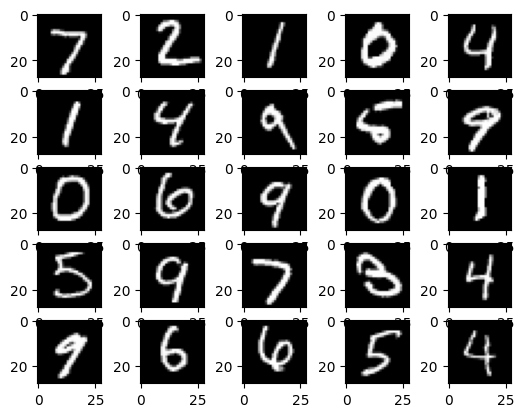

In [2]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = load_data()

print("Train: X=%s, y=%s" % (x_train.shape, y_train.shape))
print("Test: X=%s, y=%s" % (x_test.shape, y_test.shape))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i], cmap=plt.get_cmap("gray"))

plt.show()

In [3]:
orig_shape = x_train.shape[1:]
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], x_train.shape[2], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))
in_shape = x_train.shape[1:]
print("Before: {0}".format(orig_shape))
print("After: {0}".format(in_shape))

n_classes = len(unique(y_train))
print("Classes: {0}".format(n_classes))

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Before: (28, 28)
After: (28, 28, 1)
Classes: 10


In [4]:
EPOCHS = 10
BATCH_SIZE = 128
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True,
    verbose=1,
)

In [5]:
def plot_metrics(history):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    metrics = ["loss", "accuracy"]
    plt.figure(figsize=(10, 5))
    for n, metric in enumerate(metrics):
        name = metric.replace("_", " ").capitalize()
        plt.subplot(1, 2, n + 1)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label="Train")
        plt.plot(
            history.epoch,
            history.history["val_" + metric],
            color=colors[0],
            linestyle="--",
            label="Val",
        )
        plt.xlabel("Epoch")
        plt.ylabel(name)
        if metric == "loss":
            plt.ylim([0, plt.ylim()[1] + 0.1])
        else:
            plt.ylim([-0.1, 1.1])
        plt.legend()


def print_res(model):
    err = 0
    i_range = 10
    ys = zeros(i_range * i_range)

    class bcolors:
        FAIL = "\033[91m"
        ENDC = "\033[0m"

    for i in range(i_range):
        for j in range(i_range):
            idx = i * i_range + j
            image = x_test[idx]
            yhat = model.predict(asarray([image]))
            ys[idx] = argmax(yhat)
            print("%d " % ys[idx], end="")
        print()
    print("--")
    for i in range(i_range):
        for j in range(i_range):
            idx = i * i_range + j
            y = y_test[idx]
            if y == ys[idx]:
                print("%d " % y, end="")
            else:
                err = err + 1
                print(f"{bcolors.FAIL}%d {bcolors.ENDC}" % y, end="")
        print()
    return err

### Model without data augmentation

Baseline CNN without data augmentation to establish a reference point for accuracy and model complexity. The model uses a single convolutional layer followed by max pooling and a final dense output layer. With only 10,634 trainable parameters this is a compact architecture.

In [6]:
def make_model1(add_dense=False):
    model = Sequential()
    model.add(Input(shape=in_shape))
    model.add(Conv2D(32, (9, 9), activation="relu"))
    model.add(MaxPooling2D((4, 4)))
    model.add(Flatten())
    if add_dense:
        model.add(Dense(30, activation="relu"))
        model.add(Dropout(0.2))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model = make_model1(False)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 20, 20, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,634 (41.54 KB)

 Trainable params: 10,634 (41.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    validation_data=(x_test, y_test),
    batch_size=BATCH_SIZE,
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9107 - loss: 0.3495 - val_accuracy: 0.9669 - val_loss: 0.1165
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9713 - loss: 0.0979 - val_accuracy: 0.9783 - val_loss: 0.0720
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9787 - loss: 0.0712 - val_accuracy: 0.9832 - val_loss: 0.0536
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9826 - loss: 0.0574 - val_accuracy: 0.9853 - val_loss: 0.0483
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9853 - loss: 0.0488 - val_accuracy: 0.9863 - val_loss: 0.0431
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9868 - loss: 0.0435 - val_accuracy: 0.9867 - val_loss: 0.0411
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0389 - val_accuracy: 0.9872 - val_loss: 0.0382
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.

Accuracy: 0.988
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

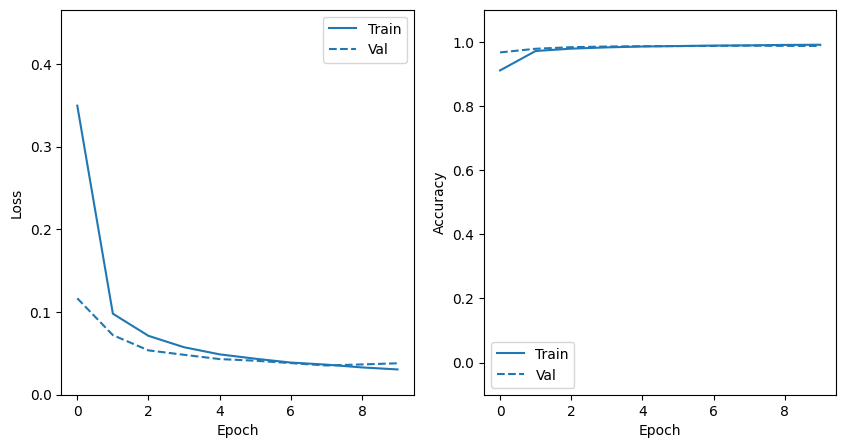

In [8]:
plot_metrics(model_history)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.3f" % acc)
err = print_res(model)

Achieved $98.8\%$ test accuracy after 10 epochs, with no early stopping triggered. The model trained quickly and improved steadily from $96.6\%$ to $98.8\%$ without signs of instability. The architecture is compact which makes training fast and inference cheap. Training accuracy closely followed validation accuracy throughout indicating minimal overfitting. This result sets a solid baseline.

### Model with data augmentation

Deeper CNN architecture combined with data augmentation because the baseline model could overfit to the exact digit positions and stroke orientations present in the training set. Add a second convolutional block to extract higher-level features, and a small dense hidden layer with dropout for regularisation.

For augmentation use small **zoom** and **rotation** since these reflect realistic handwriting variation, a writer may hold the pen at a slightly different angle or write digits at different scales.

In [9]:
def make_model2(add_dense=False):
    model = Sequential()
    model.add(Input(shape=in_shape))
    model.add(Conv2D(64, (5, 5), activation="relu"))
    model.add(MaxPooling2D((4, 4)))
    model.add(Conv2D(16, (3, 3), activation="relu"))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    if add_dense:
        model.add(Dense(100, activation="relu"))
        model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model = make_model2(True)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 16)       │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,406 (71.90 KB)

 Trainable params: 18,406 (71.90 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
datagen = ImageDataGenerator(zoom_range=0.1, rotation_range=10)

train_generator = datagen.flow(x_train, y_train, batch_size=16)

model_history = model.fit(
    train_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    validation_data=(x_test, y_test),
    batch_size=BATCH_SIZE,
)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9185 - loss: 0.2557 - val_accuracy: 0.9805 - val_loss: 0.0622
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9719 - loss: 0.0933 - val_accuracy: 0.9825 - val_loss: 0.0516
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9776 - loss: 0.0745 - val_accuracy: 0.9853 - val_loss: 0.0482
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9798 - loss: 0.0656 - val_accuracy: 0.9874 - val_loss: 0.0413
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9832 - loss: 0.0572 - val_accuracy: 0.9910 - val_loss: 0.0283
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9838 - loss: 0.0509 - val_accuracy: 0.9879 - val_loss: 0.0373
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9847 - loss: 0.0500 - val_accuracy: 0.9890 - val_loss: 0.0359
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9861 - loss: 0

Accuracy: 0.992
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
9 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

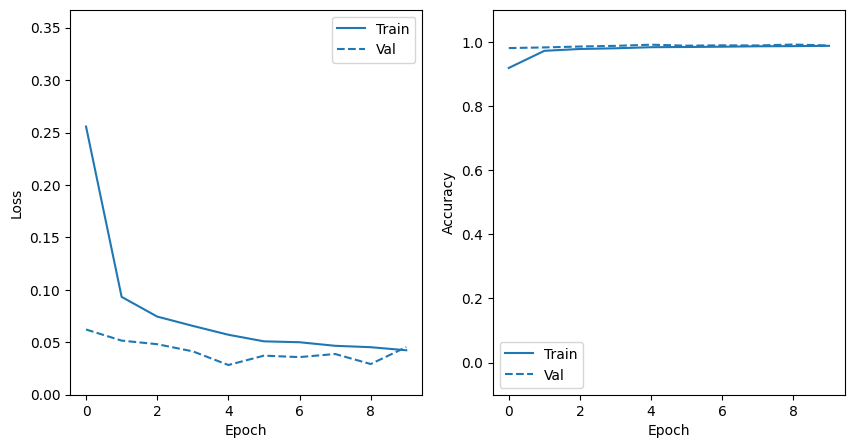

In [11]:
plot_metrics(model_history)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.3f" % acc)
err = print_res(model)

Expect the model to converge more slowly than the baseline because each epoch now contains augmented variations of the training images. Augmentation typically acts as a regulariser, so the gap between training and validation loss should be smaller. The model grew to 18,406 parameters due to the additional convolutional block and dense hidden layer, the trade-off is that we get richer feature extraction at the cost of more parameters.